![Logo_DICA2.jpg](assets/Logo_DICA2.jpg)

# Processing tiltmeter raw data

This is a code to process the raw data coming from tiltmeters installed in Gubbio's Wall. Take into consideration some particularities of this data:

1. The raw files have the extension **ADC**. Although it's a not-so-common format, it's content is like a CSV file and you can use CSV functions to read it. You only need to use **'\t'** as separator.

2. All the files have the same structure, comprising data from one day each, one register every 20 minutes. So, every file should have 72 lines.

3. The data is organized in columns without a header. In the Wall's file, we have date (DD/MM/YY) and time (HH:MM:SS) of acquisition, then charge of the batteries, temperature (°C), humidity (%) and absolute tilt (millidegree). Those last 4 data are repeated 3 times, because we have 3 stations.

4. All the file names have the same structure: **GUBBIO_ + date + .adc** . The 'date' part ha the format **YYYYMMDD**.

---

Now, some "strange" issues with the data that appear randomly:

- some files have duplicated lines. Because of that, the function **read_and_process_file** has a procedure to look for duplicates and store the non-zero value among the options
- some files have a comma as a decimal separator. Since besides the date and time, every column is a floating number, all the commas are replaced with a period to make it easier to handle later 

## Import libraries

In [5]:
import pandas as pd
import os
from tqdm import tqdm
import re

import calplot
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, MonthLocator, HourLocator
from matplotlib.colors import ListedColormap, Normalize
import numpy as np

## Custom functions

### Transform .adc files in dataframes

In [8]:
def read_and_process_file(file_path, column_names):
    """Read a file into a DataFrame, process it, and handle duplicate rows based on the second column."""
    # Read the file into a DataFrame without headers
    df = pd.read_csv(file_path, sep='\t', header=None)
    
    # Convert all decimal commas to decimal points
    df = df.replace({',': '.'}, regex=True)
    
    # Assign the proper column names
    df.columns = column_names

    # Convert relevant columns to numeric
    for col in df.columns[2:]:  # Skip 'date' and 'time' columns
        df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')
    
    # Identify duplicate rows based on the second column (time information)
    duplicates = df[df.duplicated(subset=[df.columns[1]], keep=False)]
    
    # Process duplicates if they exist
    if not duplicates.empty:
        unique_rows = []  # To store the final unique rows
        
        # Group the duplicates by the second column
        grouped_duplicates = duplicates.groupby(df.columns[1])
        
        for _, group in grouped_duplicates:
            if len(group) == 1:
                # If there's only one row in this group, no processing is needed
                unique_rows.append(group.iloc[0])
                continue

            # Compare the values in the other columns
            representative_row = group.iloc[0].copy()  # Start with the first row
            
            for col in df.columns[2:]:
                # Check if all values in this column are the same
                if len(set(group[col])) == 1:
                    representative_row[col] = group.iloc[0][col]
                else:
                    # Find the non-zero value, or choose the first non-zero if multiple different non-zero values exist
                    non_zero_values = group[col][group[col] != 0].unique()
                    if len(non_zero_values) > 0:
                        representative_row[col] = non_zero_values[0]  # Take the first non-zero value
                    else:
                        representative_row[col] = 0  # Default to zero if all are zero
                        
            # Add the processed row to the final list
            unique_rows.append(representative_row)
        
        # Create a new DataFrame with unique rows
        processed_df = pd.DataFrame(unique_rows, columns=df.columns)
        
        # Add non-duplicate rows back into the final DataFrame
        non_duplicates = df.drop_duplicates(subset=[df.columns[1]], keep=False)
        df = pd.concat([non_duplicates, processed_df], ignore_index=True)

    return df


### Extract year from filename

In [10]:
def extract_year_from_filename(file_name):
    """Extract the year from the file name."""
    # Assuming the date format in file name is `something_YYYYMMDD.txt`
    date_str = file_name.split('_')[1].split('.')[0]
    year = date_str[:4]  # Get the year part from the date
    return year

### Save data by year

In [12]:
def merge_and_save_data_by_year(data_by_year, output_folder1):
    os.makedirs(output_folder1, exist_ok=True)

    total_files = sum(len(dfs) for dfs in data_by_year.values())
    with tqdm(total=total_files, desc="Merging files", unit="file") as progress_bar:
        for year, dfs in data_by_year.items():
            merged_df = pd.DataFrame()
            for df in dfs:
                merged_df = pd.concat([merged_df, df], ignore_index=True)
                progress_bar.update(1)

            output_file = os.path.join(output_folder1, f'GUBBIO_raw_{year}.csv')
            merged_df.to_csv(output_file, index=False)

            print(f'CSV file created for year {year}: {output_file}')

### Combine all files

In [14]:
def create_combined_csv(all_data_frames, output_folder2):
    """Create a single CSV with all data, write to a file, and return the DataFrame."""
    print("Creating a single CSV with all data...")
    
    # Concatenate all dataframes into a single dataframe
    combined_df = pd.concat(all_data_frames, ignore_index=True)
    combined_df.drop_duplicates(inplace=True)
    
    # Write the combined dataframe to a CSV file
    combined_output_file = os.path.join(output_folder2, 'GUBBIO_all_raw.csv')
    combined_df.to_csv(combined_output_file, index=False)
    
    print(f'Single CSV file created with all data: {combined_output_file}')
    
    # Return the combined dataframe
    return combined_df

### Clean and compensate

In [16]:
def clean_and_compensate_data(df, date_col, time_col, columns, comp_coeff, outlier_threshold):
    """
    Clean and compensate data in a DataFrame for a specific station.

    Parameters:
    - df: The input DataFrame.
    - date_col: The name of the column representing the date.
    - time_col: The name of the column representing the time.
    - columns: A list of column names where:
        - columns[0]: Charge column (to filter out zero values).
        - columns[1]: Temperature column (used for compensation).
        - columns[3]: Absolute inclination column (used for compensation).
    - comp_coeff: The compensation coefficient.
    - outlier_threshold: The threshold value to identify and remove outliers.

    Returns:
    - A new DataFrame with only date, time, the specified columns, and the compensated 'absinc_clean' column.
    """
    # Create a copy of the original DataFrame to avoid modifying the input data
    df_cleaned = df.copy()

    # Convert relevant columns to numeric
    for col in columns:
        df_cleaned[col] = pd.to_numeric(df_cleaned[col].astype(str).str.strip(), errors='coerce')

    # Drop rows with NaN values in any of the specified columns
    df_cleaned.dropna(subset=columns, inplace=True)

    # Step 1: Filter out rows where the charge column has zero values
    df_cleaned = df_cleaned[df_cleaned[columns[0]] != 0]

    # Step 2: Remove outliers where the absolute inclination is below the outlier threshold
    df_cleaned = df_cleaned[df_cleaned[columns[3]] > outlier_threshold].copy()

    # Step 3: Apply temperature compensation
    temp_diff = (df_cleaned[columns[1]] - df_cleaned.iloc[0][columns[1]]) * comp_coeff * 1000
    df_cleaned[f'{columns[3]}_clean'] = df_cleaned[columns[3]] - temp_diff

    # Step 4: Normalize the compensated inclination data
    df_cleaned[f'{columns[3]}_clean'] -= df_cleaned[f'{columns[3]}_clean'].iloc[0]

    # Step 5: Select only the desired columns
    desired_columns = [date_col, time_col] + columns + [f'{columns[3]}_clean']
    df_cleaned = df_cleaned[desired_columns]

    return df_cleaned


## Execution code

### Creating the combined dataframes and CSV

In [19]:
# Define the folder paths
folder_path = 'data/raw_data'

output_folder1 = 'data/processed_data/year'
output_folder2 = 'data/processed_data'

images_folder = 'img_new'

# Define the proper column names
column_names = [
    'date', 'time', 'st01_charge', 'st01_temp', 'st01_hum', 'st01_absinc',
    'st02_charge', 'st02_temp', 'st02_hum', 'st02_absinc',
    'st03_charge', 'st03_temp', 'st03_hum', 'st03_absinc'
]

In [20]:
# Initialize data structures
data_by_year = {}
all_data_frames = []

# Define the regular expression pattern for your file names
pattern = re.compile(r'^GUBBIO_\d{8}\.adc$')

# Get the list of all files in the folder and filter them
file_list = [f for f in os.listdir(folder_path) if pattern.match(f)]

# Initialize the progress bar for the overall processing
progress_bar = tqdm(total=len(file_list), desc="Files processed", unit="file")

# Process each file
for file_name in file_list:
    file_path = os.path.join(folder_path, file_name)
    
    # Read and process the file
    df = read_and_process_file(file_path, column_names)
    
    # Extract the year from the file name
    year = extract_year_from_filename(file_name)
    
    # If the year is not in the dictionary, initialize a list for it
    if year not in data_by_year:
        data_by_year[year] = []
    
    # Append the dataframe to the list for this year
    data_by_year[year].append(df)

    # Add the dataframe to the list for the combined CSV
    all_data_frames.append(df)
    
    # Update the progress bar
    progress_bar.update(1)

# Close the progress bar
progress_bar.close()

# Merge data by year and save to CSV files
merge_and_save_data_by_year(data_by_year, output_folder1)

# Create a combined CSV with all data
combined_df = create_combined_csv(all_data_frames, output_folder2)

Merging files:  23%|█████████████▉                                              | 442/1911 [00:00<00:00, 2272.61file/s]

CSV file created for year 2018: data/processed_data/year\GUBBIO_raw_2018.csv


Merging files:  35%|█████████████████████                                       | 671/1911 [00:00<00:00, 1629.60file/s]

CSV file created for year 2019: data/processed_data/year\GUBBIO_raw_2019.csv


Merging files:  61%|████████████████████████████████████▏                      | 1172/1911 [00:00<00:00, 1783.15file/s]

CSV file created for year 2020: data/processed_data/year\GUBBIO_raw_2020.csv


Merging files:  83%|████████████████████████████████████████████████▉          | 1586/1911 [00:00<00:00, 1679.87file/s]

CSV file created for year 2021: data/processed_data/year\GUBBIO_raw_2021.csv
CSV file created for year 2022: data/processed_data/year\GUBBIO_raw_2022.csv
CSV file created for year 2023: data/processed_data/year\GUBBIO_raw_2023.csv


Merging files: 100%|███████████████████████████████████████████████████████████| 1911/1911 [00:01<00:00, 1621.75file/s]


CSV file created for year 2024: data/processed_data/year\GUBBIO_raw_2024.csv
CSV file created for year 2025: data/processed_data/year\GUBBIO_raw_2025.csv
Creating a single CSV with all data...
Single CSV file created with all data: data/processed_data\GUBBIO_all_raw.csv


### Visualizing missing data

#### Color ramp

In [85]:
# Create a custom colormap for all calendar charts
base_cmap = plt.cm.winter  # Base colormap
cmap_colors = base_cmap(np.arange(base_cmap.N))  # Extract the colors from the base colormap
cmap_colors[0] = np.array([1, 1, 1, 0])  # Set the first color (for zero) to white
custom_cmap = ListedColormap(cmap_colors)

#### Counting missing dates

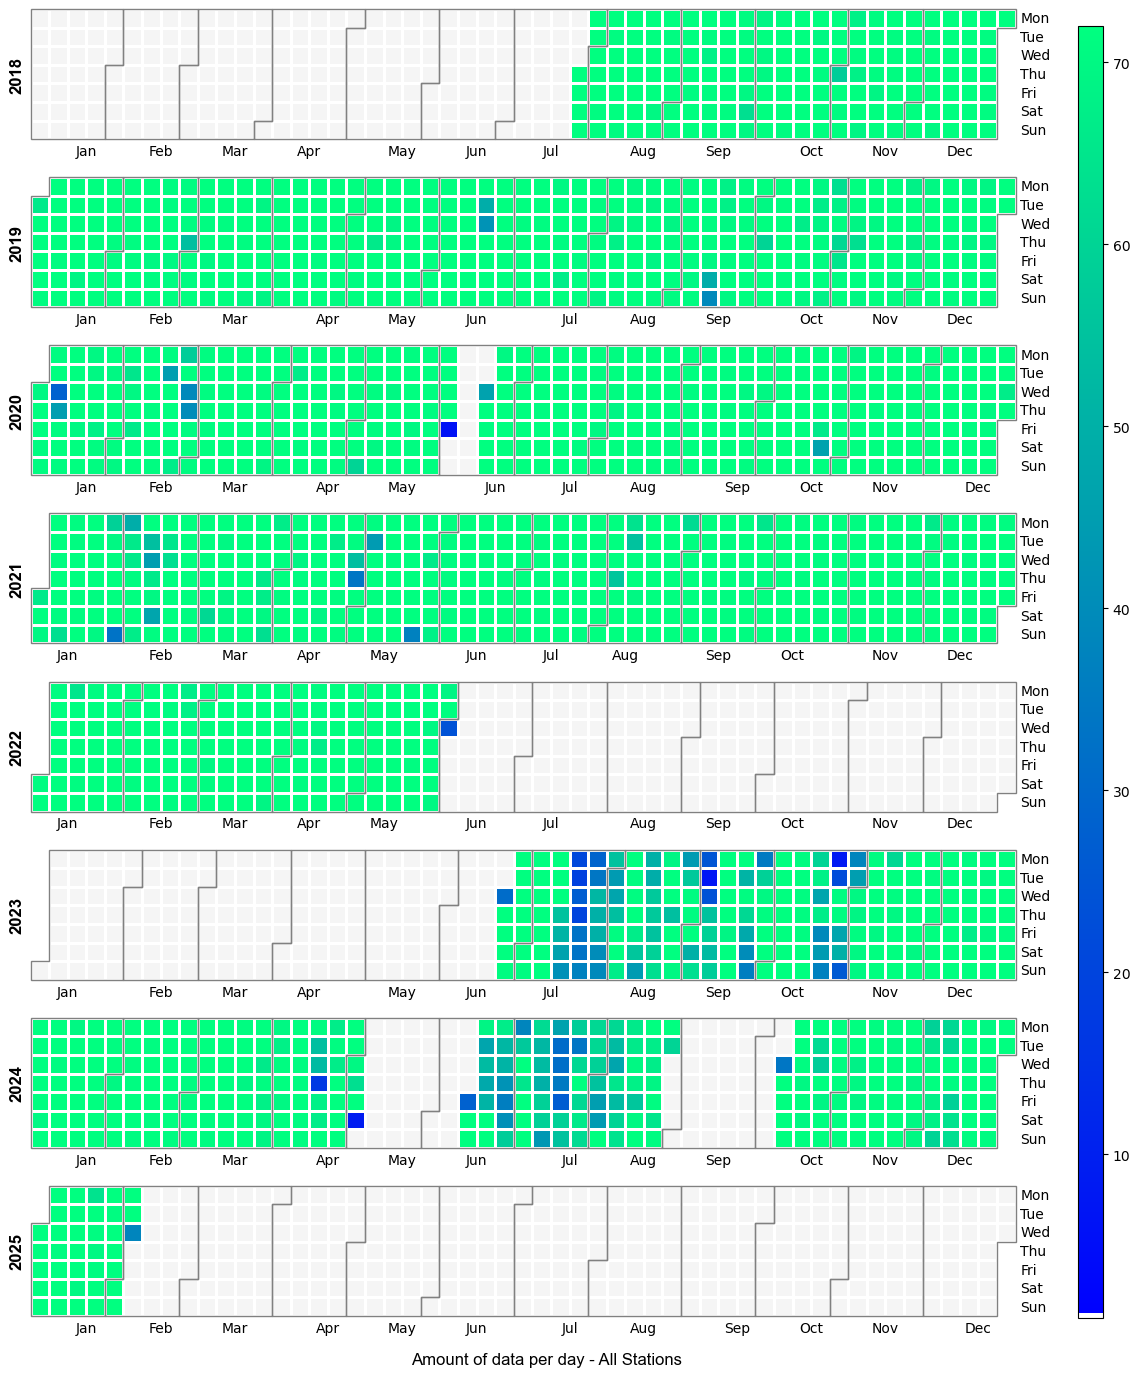

In [88]:
'''All Stations'''

# Ensure the 'date' column is in datetime format
combined_df['date'] = pd.to_datetime(combined_df['date'], format='%d/%m/%y')

# Count the number of rows per day
daily_counts = combined_df['date'].value_counts().sort_index()

# Calculate global minimum and maximum for the color scale, excluding zero
masked_counts = daily_counts.mask(daily_counts == 0)
global_min = masked_counts.min()
global_max = masked_counts.max()

# Normalize the color scale, ensuring zero is treated separately
norm = Normalize(vmin=global_min, vmax=global_max)

# Create a calendar plot using calplot with the specified parameters and custom colormap
calplot.calplot(
    daily_counts,
    cmap=custom_cmap,
    suptitle='Amount of data per day - All Stations',
    vmin=global_min,
    vmax=global_max,
    colorbar=True,
    suptitle_kws={'y': 0.00, 'fontsize': 12, 'fontname': 'Arial'},
    yearlabel_kws={'fontsize': 12, 'color': 'black', 'fontname': 'Arial'},
    tight_layout=True
)

# Construct the full file paths for the SVG and PNG files
svg_path = os.path.join(images_folder, 'amount_of_data.svg')
png_path = os.path.join(images_folder, 'amount_of_data.png')

# Save the plot as an SVG file
plt.savefig(svg_path, format='svg', bbox_inches='tight')

# Save the plot as a high-resolution PNG file
plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

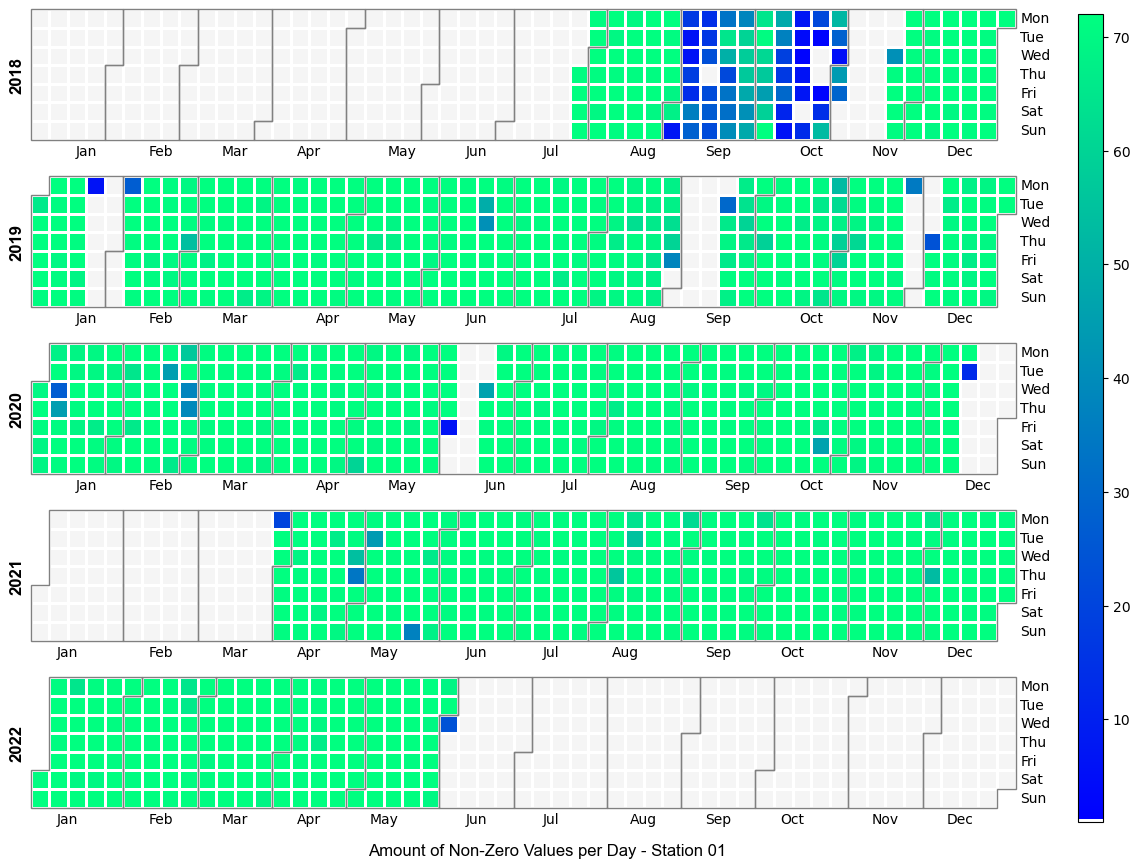

In [90]:
'''Station 01'''

# Ensure the 'date' column is in datetime format
combined_df['date'] = pd.to_datetime(combined_df['date'], format='%d/%m/%y')

# Replace 'your_column_name' with the actual column name you want to analyze
column_to_analyze = 'st01_absinc'

# Count non-zero values per day in the specific column
daily_counts = combined_df[combined_df[column_to_analyze] != 0].groupby('date').size()

# Calculate global minimum and maximum for the color scale, excluding zero
masked_counts = daily_counts.mask(daily_counts == 0)
global_min = masked_counts.min()
global_max = masked_counts.max()

# Normalize the color scale, ensuring zero is treated separately
norm = Normalize(vmin=global_min, vmax=global_max)

# Create a calendar plot using calplot with the specified parameters and custom colormap
calplot.calplot(
    daily_counts,
    cmap=custom_cmap,
    suptitle=f'Amount of Non-Zero Values per Day - Station 01',
    vmin=global_min,
    vmax=global_max,
    colorbar=True,
    suptitle_kws={'y': 0.00, 'fontsize': 12, 'fontname': 'Arial'},
    yearlabel_kws={'fontsize': 12, 'color': 'black', 'fontname': 'Arial'},
    tight_layout=True
)

# Construct the full file paths for the SVG and PNG files
svg_path = os.path.join(images_folder, 'amount_of_data_st01.svg')
png_path = os.path.join(images_folder, 'amount_of_data_st01.png')

# Save the plot as an SVG file
plt.savefig(svg_path, format='svg', bbox_inches='tight')

# Save the plot as a high-resolution PNG file
plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

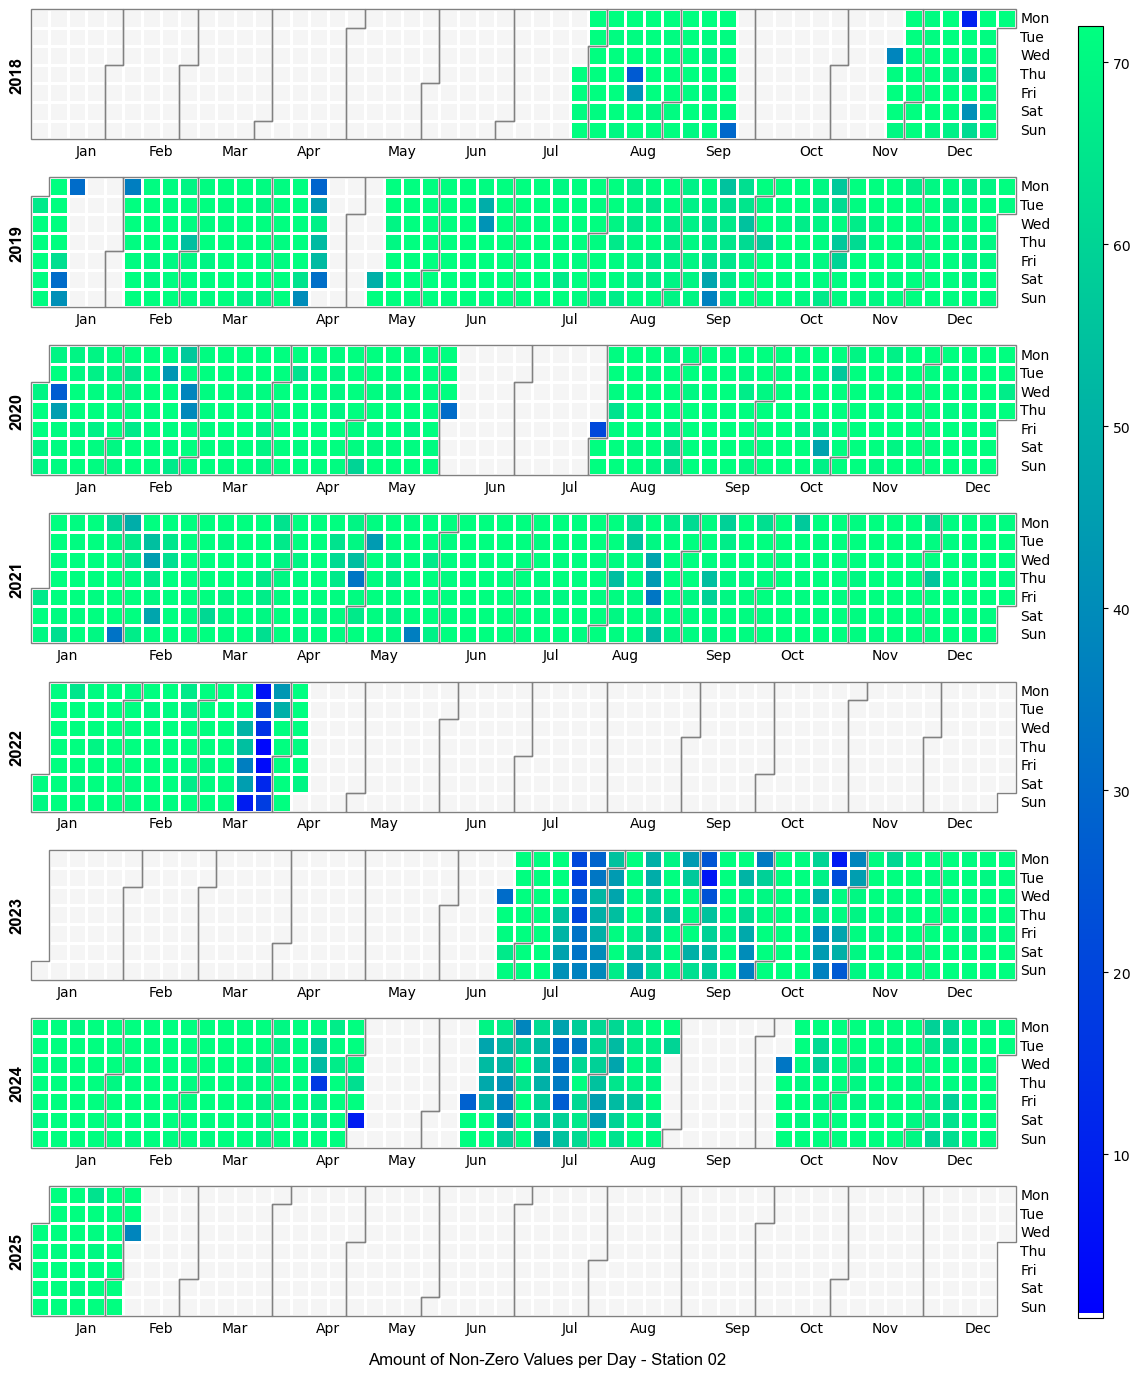

In [92]:
'''Station 02'''

# Ensure the 'date' column is in datetime format
combined_df['date'] = pd.to_datetime(combined_df['date'], format='%d/%m/%y')

# Replace 'your_column_name' with the actual column name you want to analyze
column_to_analyze = 'st02_absinc'

# Count non-zero values per day in the specific column
daily_counts = combined_df[combined_df[column_to_analyze] != 0].groupby('date').size()

# Calculate global minimum and maximum for the color scale, excluding zero
masked_counts = daily_counts.mask(daily_counts == 0)
global_min = masked_counts.min()
global_max = masked_counts.max()

# Normalize the color scale, ensuring zero is treated separately
norm = Normalize(vmin=global_min, vmax=global_max)

# Create a calendar plot using calplot with the specified parameters and custom colormap
calplot.calplot(
    daily_counts,
    cmap=custom_cmap,
    suptitle=f'Amount of Non-Zero Values per Day - Station 02',
    vmin=global_min,
    vmax=global_max,
    colorbar=True,
    suptitle_kws={'y': 0.00, 'fontsize': 12, 'fontname': 'Arial'},
    yearlabel_kws={'fontsize': 12, 'color': 'black', 'fontname': 'Arial'},
    tight_layout=True
)

# Construct the full file paths for the SVG and PNG files
svg_path = os.path.join(images_folder, 'amount_of_data_st02.svg')
png_path = os.path.join(images_folder, 'amount_of_data_st02.png')

# Save the plot as an SVG file
plt.savefig(svg_path, format='svg', bbox_inches='tight')

# Save the plot as a high-resolution PNG file
plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

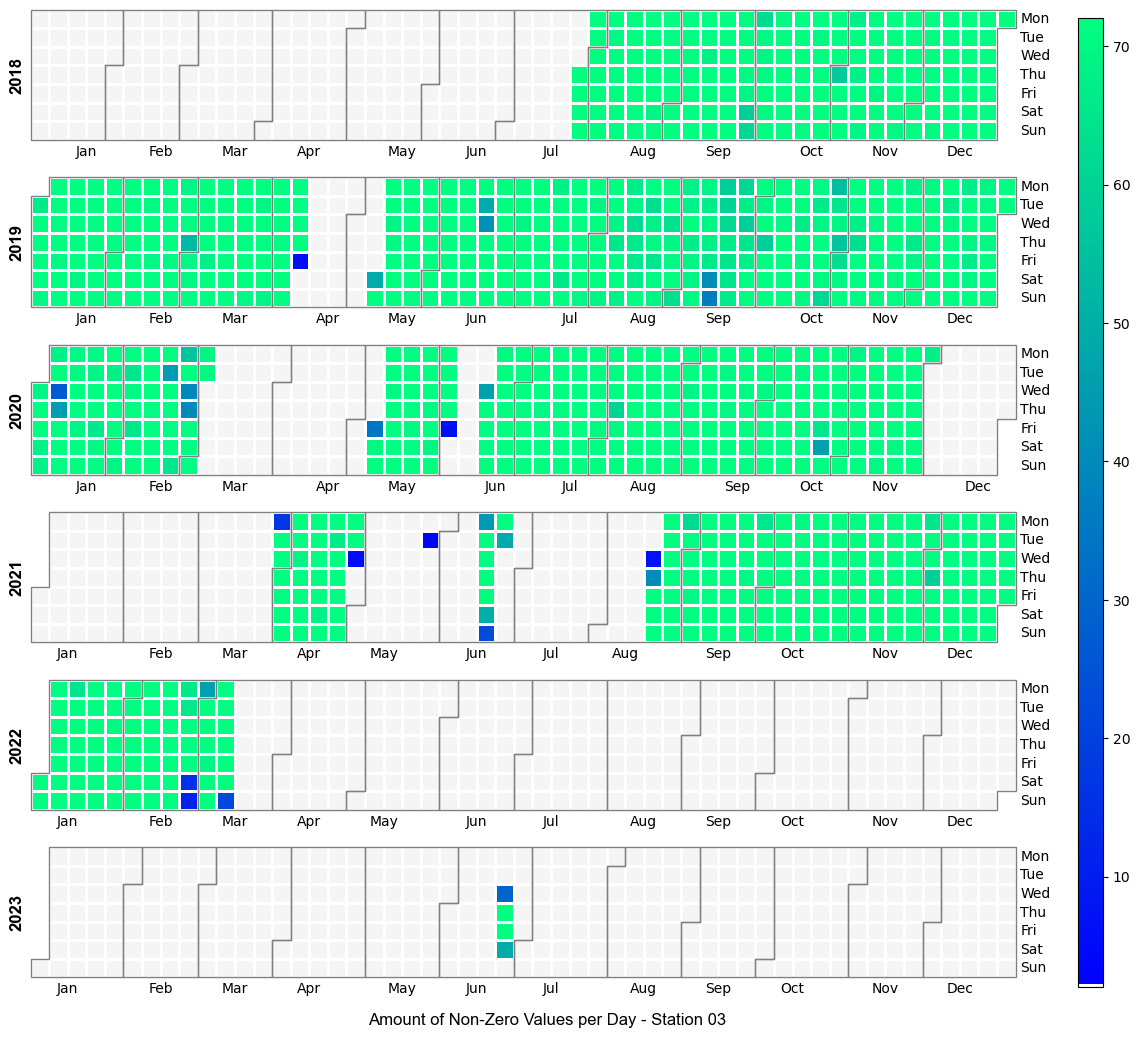

In [94]:
'''Station 03'''

# Ensure the 'date' column is in datetime format
combined_df['date'] = pd.to_datetime(combined_df['date'], format='%d/%m/%y')

# Replace 'your_column_name' with the actual column name you want to analyze
column_to_analyze = 'st03_absinc'

# Count non-zero values per day in the specific column
daily_counts = combined_df[combined_df[column_to_analyze] != 0].groupby('date').size()

# Calculate global minimum and maximum for the color scale, excluding zero
masked_counts = daily_counts.mask(daily_counts == 0)
global_min = masked_counts.min()
global_max = masked_counts.max()

# Normalize the color scale, ensuring zero is treated separately
norm = Normalize(vmin=global_min, vmax=global_max)

# Create a calendar plot using calplot with the specified parameters and custom colormap
calplot.calplot(
    daily_counts,
    cmap=custom_cmap,
    suptitle=f'Amount of Non-Zero Values per Day - Station 03',
    vmin=global_min,
    vmax=global_max,
    colorbar=True,
    suptitle_kws={'y': 0.00, 'fontsize': 12, 'fontname': 'Arial'},
    yearlabel_kws={'fontsize': 12, 'color': 'black', 'fontname': 'Arial'},
    tight_layout=True
)

# Construct the full file paths for the SVG and PNG files
svg_path = os.path.join(images_folder, 'amount_of_data_st03.svg')
png_path = os.path.join(images_folder, 'amount_of_data_st03.png')

# Save the plot as an SVG file
plt.savefig(svg_path, format='svg', bbox_inches='tight')

# Save the plot as a high-resolution PNG file
plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

### Cleaning, compensating and normalize data

In [96]:
column_names

['date',
 'time',
 'st01_charge',
 'st01_temp',
 'st01_hum',
 'st01_absinc',
 'st02_charge',
 'st02_temp',
 'st02_hum',
 'st02_absinc',
 'st03_charge',
 'st03_temp',
 'st03_hum',
 'st03_absinc']

In [107]:
# Define parameters for the function
date_col = 'date'
time_col = 'time'
columns = ['st01_charge', 'st01_temp', 'st01_hum', 'st01_absinc']
comp_coeff = 0.005
outlier_threshold = -500

# Call the function
cleaned_df_st01 = clean_and_compensate_data(
    combined_df,
    date_col,
    time_col,
    columns,
    comp_coeff,
    outlier_threshold
)

# Save the cleaned DataFrame to a CSV file
cleaned_df_st01.to_csv('data/processed_data/GUBBIO_ST01_PROCESSED.csv', index=False)

# Display the cleaned DataFrame
cleaned_df_st01.head()

,date,time,st01_charge,st01_temp,st01_hum,st01_absinc,st01_absinc_clean
0,2018-07-25,23:40:00,3.50,21.965,44.910,1942.625,0.000
1,2018-07-26,00:00:00,3.50,21.695,45.220,1940.625,-0.650
3,2018-07-26,00:40:00,3.49,21.090,45.005,1936.125,-2.125
4,2018-07-26,01:00:00,3.50,20.760,45.405,1934.625,-1.975
5,2018-07-26,01:20:00,3.50,20.900,46.130,1933.250,-4.050


In [109]:
# Define parameters for the function
date_col = 'date'
time_col = 'time'
columns = ['st02_charge', 'st02_temp', 'st02_hum', 'st02_absinc']
comp_coeff = 0.005
outlier_threshold = -500

# Call the function
cleaned_df_st02 = clean_and_compensate_data(
    combined_df,
    date_col,
    time_col,
    columns,
    comp_coeff,
    outlier_threshold
)

# Save the cleaned DataFrame to a CSV file
cleaned_df_st02.to_csv('data/processed_data/GUBBIO_ST02_PROCESSED.csv', index=False)

# Display the cleaned DataFrame
cleaned_df_st02.head()

,date,time,st02_charge,st02_temp,st02_hum,st02_absinc,st02_absinc_clean
0,2018-07-25,23:40:00,3.49,21.750,45.115,2122.750,0.000
1,2018-07-26,00:00:00,3.47,21.555,45.155,2122.125,0.350
2,2018-07-26,00:20:00,3.47,21.365,45.040,2121.000,0.175
3,2018-07-26,00:40:00,3.48,21.150,44.500,2120.875,1.125
4,2018-07-26,01:00:00,3.47,20.980,45.195,2120.375,1.475


In [111]:
# Define parameters for the function
date_col = 'date'
time_col = 'time'
columns = ['st03_charge', 'st03_temp', 'st03_hum', 'st03_absinc']
comp_coeff = 0.005
outlier_threshold = -500

# Call the function
cleaned_df_st03 = clean_and_compensate_data(
    combined_df,
    date_col,
    time_col,
    columns,
    comp_coeff,
    outlier_threshold
)

# Save the cleaned DataFrame to a CSV file
cleaned_df_st03.to_csv('data/processed_data/GUBBIO_ST03_PROCESSED.csv', index=False)

# Display the cleaned DataFrame
cleaned_df_st03.head()

,date,time,st03_charge,st03_temp,st03_hum,st03_absinc,st03_absinc_clean
1,2018-07-26,00:00:00,3.48,20.87,50.095,2077.125,0.000
2,2018-07-26,00:20:00,3.49,20.70,48.595,2076.625,0.350
3,2018-07-26,00:40:00,3.48,20.51,49.005,2075.375,0.050
4,2018-07-26,01:00:00,3.48,20.45,49.120,2075.375,0.350
5,2018-07-26,01:20:00,3.48,20.14,50.200,2073.000,-0.475
